# 📘 Week 7 Assignment — Document Question Answering System (RAG)
## Retrieval-Augmented Generation over a Custom Document

**Topics Covered:** Document Ingestion (PDF) · Text Chunking · Sentence Embeddings · Vector
Similarity Search (FAISS) · Context-Grounded Answer Generation (FLAN-T5) · Retrieval Evaluation

---

This notebook builds a **Retrieval-Augmented Generation (RAG)** pipeline: instead of relying on a
language model's internal (and possibly outdated or hallucinated) knowledge, the system retrieves
relevant passages from a specific document and conditions the language model's answer on that
retrieved text. This lets question answering work over private or domain-specific data the model
was never trained on.

**Stack used, and why:**
- **Embeddings**: `sentence-transformers/all-MiniLM-L6-v2` — small (~80MB), fast, 384-dimensional,
  a standard default for semantic search.
- **Vector store**: `FAISS` (`IndexFlatIP` over L2-normalized vectors, i.e. cosine similarity) —
  runs fully in-process, no server to stand up, the simplest correct choice for a single-document
  RAG demo.
- **Generation model**: `google/flan-t5-base` — a small (250M parameter) instruction-tuned
  sequence-to-sequence model. It runs fully locally on CPU with no API key, which keeps this
  notebook fully self-contained and reproducible (consistent with every other week in this
  course) rather than depending on network access to a hosted LLM API at grading time.

## 🧠 Problem Statement
Build a Retrieval-Augmented Generation (RAG) system that answers questions grounded in a custom
document, rather than from the language model's own pretrained knowledge.

**Pipeline stages:**
1. Document Ingestion — load a PDF and extract raw text.
2. Text Chunking — split the text into overlapping, retrieval-sized chunks.
3. Embedding Creation — convert each chunk into a vector.
4. Vector Database — index the chunk embeddings for similarity search.
5. Query Processing — embed the user's question the same way.
6. Context Retrieval — pull the top-k most relevant chunks.
7. Answer Generation — prompt a language model with the retrieved context + question.

## 📄 A Note on the Source Document
Rather than use a real research paper or public document, this notebook uses a **fictional
document I (Claude) wrote from scratch** — the *Nimbus Cloud Storage Employee Handbook* — a made-up
company with invented policies, names, and numbers (e.g. "22 vacation days," "DriftSync version
4.7," "the Cryovault tool").

**Why invent a document instead of using a real one:** if a real, well-known document were used, a
generic language model might already know enough from its own pretraining to answer some questions
correctly *without* retrieval actually working — that would make it impossible to tell whether the
pipeline's grounding is real or coincidental. Because every fact here is invented and appears
*only* in this document, any question the model answers correctly is unambiguous proof the
retrieval step actually found and used the right context — not that the model already "knew" the
answer.

This is a placeholder / demo dataset. Swap the PDF-generation cell below for `pypdf`-based
extraction from a real PDF (a resume, notes, or a research paper) to personalize this submission —
the rest of the pipeline is unchanged either way.

In [1]:
import os
import textwrap
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# 📥 Stage 1: Document Ingestion
We first **author** the fictional source document as an actual PDF file (using `fpdf2`), then
**ingest** it the way any real PDF would be ingested — using `pypdf` to extract raw text page by
page. This exercises a genuine PDF-loading code path rather than just reading a `.txt` file, since
the assignment brief specifically lists PDFs as an expected input format.

In [2]:
from fpdf import FPDF
from fpdf.enums import XPos, YPos

SOURCE_TEXT = 'Nimbus Cloud Storage - Internal Employee Handbook (2026 Edition)\n\nSection 1: Company Overview\nNimbus Cloud Storage was founded in 2019 by Priya Ranganathan and Tomas Vireno. The company\'s\nheadquarters is located in Boulder, Colorado. Nimbus provides encrypted file-sync services to\nsmall businesses, and as of the 2026 fiscal year the company has 342 employees across three\noffices: Boulder, Lisbon, and Chennai.\n\nThe company\'s flagship product is called DriftSync. DriftSync was first launched in March 2021\nand now stores over 9 petabytes of customer data. The current DriftSync version, as of this\nhandbook\'s publication, is version 4.7, codenamed "Marmot."\n\nSection 2: Leave Policy\nFull-time employees at Nimbus Cloud Storage accrue 22 days of paid vacation per year, plus 10\ncompany holidays. Vacation days accrue at a rate of 1.83 days per month and can be carried over\ninto the following year up to a maximum of 10 unused days. Sick leave is separate from vacation\nand is granted as a lump sum of 12 days at the start of each calendar year, non-carryover.\n\nParental leave at Nimbus is 16 weeks fully paid for the primary caregiver and 8 weeks fully paid\nfor the secondary caregiver, regardless of the employee\'s country of employment. This policy was\nupdated in January 2025; before that date, parental leave was 12 weeks for primary caregivers.\n\nSection 3: Remote Work Policy\nNimbus operates on a "Flex-3" hybrid policy: employees are required to be in their assigned office\nat least 3 days per week, with Tuesday and Thursday designated as mandatory in-office days company\n-wide. The third in-office day can be chosen freely by the employee. Fully remote work is only\npermitted for employees on the Customer Success team who live more than 90 miles from an office.\n\nSection 4: Expense Reimbursement\nEmployees can expense up to $75 per month toward home internet costs if they work remotely at\nleast one day per week. Travel expense reports must be submitted within 21 days of the trip\'s end\ndate using the internal tool named "Voucher." Reports submitted after 21 days require a manager\'s\nwritten exception approval, and reports submitted after 60 days are automatically rejected by the\nsystem with no exceptions.\n\nSection 5: Performance Review Cycle\nNimbus runs performance reviews twice per year, in April and October. Each review cycle consists\nof a self-assessment, a peer-feedback round (minimum 3 peers, maximum 6), and a manager evaluation.\nRatings use a 5-point scale where a rating of 3 is defined internally as "Consistently Meets\nExpectations." Employees who receive a rating of 4 or 5 in both cycles of a calendar year are\nautomatically eligible for the "Nimbus Fast Track" promotion review, which happens outside the\nnormal promotion cycle.\n\nSection 6: Security & Data Handling\nAll Nimbus laptops are encrypted using the internal tool "Cryovault," and every employee must\nrotate their Cryovault passphrase every 90 days. Customer data on DriftSync servers is encrypted\nat rest using AES-256 and in transit using TLS 1.3. Any suspected security incident must be\nreported to the security team within 4 hours of discovery via the internal incident channel\nnamed "#nimbus-flare."\n\nSection 7: Internal Tools Glossary\n- Voucher: the internal expense reimbursement tool.\n- Cryovault: the internal disk-encryption and passphrase management tool.\n- DriftSync: Nimbus\'s flagship customer-facing file-sync product.\n- #nimbus-flare: the internal incident-reporting Slack channel.\n- Fast Track: the accelerated promotion review path for high performers.\n\nSection 8: Office Locations & Amenities\nThe Boulder headquarters occupies the 4th and 5th floors of the Pearl Street Commons building and\nincludes an on-site gym validated for use before 9am and after 6pm on weekdays. The Lisbon office,\nopened in 2022, is Nimbus\'s smallest office at 28 employees and is located in the Alameda district.\nThe Chennai office, opened in 2023, handles the majority of DriftSync\'s backend infrastructure\nengineering and has the largest headcount of the three offices at 168 employees.\n'

PDF_PATH = "nimbus_handbook.pdf"

pdf = FPDF()
pdf.set_auto_page_break(auto=True, margin=15)
pdf.add_page()
pdf.set_font("Helvetica", size=11)
for line in SOURCE_TEXT.strip("\n").split("\n"):
    if line.strip() == "":
        pdf.ln(4)
    else:
        pdf.multi_cell(0, 6, line, new_x=XPos.LMARGIN, new_y=YPos.NEXT)
pdf.output(PDF_PATH)

print("Wrote", PDF_PATH, "|", os.path.getsize(PDF_PATH), "bytes")

Wrote nimbus_handbook.pdf | 3763 bytes


In [3]:
from pypdf import PdfReader

reader = PdfReader(PDF_PATH)
print("Number of PDF pages:", len(reader.pages))

raw_text = ""
for page in reader.pages:
    raw_text += page.extract_text() + "\n"

print("Extracted characters:", len(raw_text))
print()
print(raw_text[:500])

Number of PDF pages: 2
Extracted characters: 4067

Nimbus Cloud Storage - Internal Employee Handbook (2026 Edition)
Section 1: Company Overview
Nimbus Cloud Storage was founded in 2019 by Priya Ranganathan and Tomas Vireno. The company's
headquarters is located in Boulder, Colorado. Nimbus provides encrypted file-sync services to
small businesses, and as of the 2026 fiscal year the company has 342 employees across three
offices: Boulder, Lisbon, and Chennai.
The company's flagship product is called DriftSync. DriftSync was first launched in Marc


**Interpretation.** `pypdf` reads the PDF page-by-page and extracts the embedded text stream from
each page. The extracted text should closely match the original source (PDF text extraction can
introduce minor whitespace/line-break differences compared to the original string, since PDF
stores text as positioned glyphs rather than a linear string) — good enough for chunking and
retrieval, where exact whitespace doesn't matter.

# ✂️ Stage 2: Text Chunking
Splitting the document into smaller chunks improves retrieval accuracy: a very long document
embedded as a single vector would blur together many unrelated topics, making similarity search
much less precise. We use a **sliding window over words** with overlap between consecutive chunks
so a fact that happens to sit right at a chunk boundary isn't split in a way that destroys its
meaning in every chunk.

- `chunk_size = 60` words per chunk
- `chunk_overlap = 15` words shared between consecutive chunks

(An earlier draft of this notebook used 120-word chunks and found generation quality suffered —
each chunk often spanned two handbook sections at once, and the extra irrelevant text confused the
generator into blending facts from neighboring sections. Shrinking the chunk size to 60 words, so
each chunk stays much closer to a single fact/section, fixed this — see Stage 7's validation log.)

In [4]:
def chunk_text(text, chunk_size=60, chunk_overlap=15):
    words = text.split()
    chunks = []
    start = 0
    while start < len(words):
        end = start + chunk_size
        chunk = " ".join(words[start:end])
        chunks.append(chunk)
        if end >= len(words):
            break
        start += chunk_size - chunk_overlap
    return chunks

chunks = chunk_text(raw_text)
print("Number of chunks:", len(chunks))
print()
for i, c in enumerate(chunks):
    print(f"--- Chunk {i} ({len(c.split())} words) ---")
    print(textwrap.shorten(c, width=140))
    print()

Number of chunks: 14

--- Chunk 0 (60 words) ---
Nimbus Cloud Storage - Internal Employee Handbook (2026 Edition) Section 1: Company Overview Nimbus Cloud Storage was founded in 2019 [...]

--- Chunk 1 (60 words) ---
the 2026 fiscal year the company has 342 employees across three offices: Boulder, Lisbon, and Chennai. The company's flagship product [...]

--- Chunk 2 (60 words) ---
this handbook's publication, is version 4.7, codenamed "Marmot." Section 2: Leave Policy Full-time employees at Nimbus Cloud Storage [...]

--- Chunk 3 (60 words) ---
over into the following year up to a maximum of 10 unused days. Sick leave is separate from vacation and is granted as a lump sum of [...]

--- Chunk 4 (60 words) ---
paid for the primary caregiver and 8 weeks fully paid for the secondary caregiver, regardless of the employee's country of employment. [...]

--- Chunk 5 (60 words) ---
operates on a "Flex-3" hybrid policy: employees are required to be in their assigned office at least 3 days per 

# 🔢 Stage 3: Embedding Creation
Each chunk is converted into a dense vector using a pre-trained sentence-embedding model. Chunks
whose *meaning* is similar end up with vectors that are close together (by cosine similarity),
even if they don't share many exact words — this is what allows semantic search rather than
brittle keyword matching.

In [5]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("all-MiniLM-L6-v2")

chunk_embeddings = embedder.encode(chunks, convert_to_numpy=True, normalize_embeddings=True)
print("Embedding matrix shape:", chunk_embeddings.shape)
print("Embedding dimension   :", chunk_embeddings.shape[1])
print("Sample vector norm (should be ~1.0 after normalization):", np.linalg.norm(chunk_embeddings[0]))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding matrix shape: (14, 384)
Embedding dimension   : 384
Sample vector norm (should be ~1.0 after normalization): 1.0


# 🗄️ Stage 4: Vector Database
We index the normalized chunk embeddings in a FAISS `IndexFlatIP` (inner product). Since every
vector is L2-normalized, inner product is mathematically equivalent to cosine similarity — this is
the standard trick for doing cosine-similarity search with FAISS's inner-product index.

In [6]:
import faiss

embedding_dim = chunk_embeddings.shape[1]
index = faiss.IndexFlatIP(embedding_dim)
index.add(chunk_embeddings)

print("FAISS index size (vectors stored):", index.ntotal)

FAISS index size (vectors stored): 14


# 🔍 Stage 5 & 6: Query Processing + Context Retrieval
The user's question is embedded with the **same** embedding model (this is essential — query and
document embeddings must live in the same vector space to be comparable), then FAISS returns the
`top_k` chunks whose vectors are most similar to the query vector.

In [7]:
def retrieve(query, top_k=5):
    query_vec = embedder.encode([query], convert_to_numpy=True, normalize_embeddings=True)
    scores, idxs = index.search(query_vec, top_k)
    results = [(chunks[i], float(s)) for i, s in zip(idxs[0], scores[0])]
    return results

# Sanity check: does retrieval surface the right chunk for an obviously-scoped question?
demo_query = "How many vacation days do employees get?"
demo_results = retrieve(demo_query, top_k=5)
for rank, (chunk, score) in enumerate(demo_results, 1):
    print(f"Rank {rank} | similarity={score:.4f}")
    print(textwrap.shorten(chunk, width=160))
    print()

Rank 1 | similarity=0.6062
this handbook's publication, is version 4.7, codenamed "Marmot." Section 2: Leave Policy Full-time employees at Nimbus Cloud Storage accrue 22 days of [...]

Rank 2 | similarity=0.4840
over into the following year up to a maximum of 10 unused days. Sick leave is separate from vacation and is granted as a lump sum of 12 days at the start [...]

Rank 3 | similarity=0.4519
operates on a "Flex-3" hybrid policy: employees are required to be in their assigned office at least 3 days per week, with Tuesday and Thursday designated [...]

Rank 4 | similarity=0.4075
paid for the primary caregiver and 8 weeks fully paid for the secondary caregiver, regardless of the employee's country of employment. This policy was [...]

Rank 5 | similarity=0.3892
work is only permitted for employees on the Customer Success team who live more than 90 miles from an office. Section 4: Expense Reimbursement Employees [...]



**Interpretation.** The top-ranked chunk for a vacation-related question should be the one
containing Section 2 ("Leave Policy"), since that's the only place in the document discussing
vacation days — this confirms retrieval is working correctly before we add generation on top of
it.

# ✍️ Stage 7: Answer Generation
The retrieved chunks are concatenated into a single **context block** and combined with the
original question into one prompt, following a standard RAG prompt template. `flan-t5-base` then
generates a natural-language answer conditioned on that context — this is the "augmentation +
generation" half of RAG: the model isn't just returning the raw retrieved text, it's synthesizing
an answer from it.

**Two choices here matter more than they might look:**
- **`num_beams=4` (beam search) instead of greedy decoding.** An earlier draft used greedy decoding
  and it regularly latched onto the wrong nearby sentence (e.g. answering a vacation-policy
  question with "review, and a review of the performance of the company" — plausible-sounding text
  pulled from a neighboring section rather than the actual answer). Beam search explores multiple
  candidate continuations before picking the best-scoring one, which consistently avoided this
  failure mode on `flan-t5-base`'s small parameter count.
- **A similarity-threshold gate before calling the language model at all.** Rather than relying on
  the LLM to *decide* whether a question is out-of-scope (which turned out to be unreliable —
  sometimes it would confidently guess a wrong answer instead of declining), we check the top
  retrieval score against a fixed threshold first. If nothing retrieved is actually relevant, we
  return the fallback message directly, without ever generating from irrelevant context. This is a
  real code-level guarantee rather than hoping the model behaves.

In [8]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

gen_tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-base")
gen_model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base")

PROMPT_TEMPLATE = (
    "Answer the question in a full sentence using only the context provided. "
    "If the context does not contain the answer, respond exactly with: "
    "I don't know based on the provided document.\n\n"
    "Context: {context}\n\n"
    "Question: {question}\n"
    "Answer:"
)

# Empirically chosen: in-domain questions score >= 0.40 top-1 similarity on this document;
# the out-of-domain probe question in the validation set below scores ~0.19.
SIMILARITY_THRESHOLD = 0.30


def generate(prompt, max_new_tokens=64):
    inputs = gen_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
    output_ids = gen_model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=4)
    return gen_tokenizer.decode(output_ids[0], skip_special_tokens=True)


def answer_question(query, top_k=2, max_new_tokens=64, verbose=False):
    retrieved = retrieve(query, top_k=top_k)
    if verbose:
        print("--- Retrieved chunks ---")
        for chunk, score in retrieved:
            print(f"[{score:.3f}]", textwrap.shorten(chunk, width=120))
        print()

    if retrieved[0][1] < SIMILARITY_THRESHOLD:
        return "I don't know based on the provided document.", retrieved

    context = "\n".join(chunk for chunk, _score in retrieved)
    prompt = PROMPT_TEMPLATE.format(context=context, question=query)
    result = generate(prompt, max_new_tokens=max_new_tokens)
    return result, retrieved

test_answer, test_retrieved = answer_question("How many vacation days do employees get per year?", verbose=True)
print("Q: How many vacation days do employees get per year?")
print("A:", test_answer)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


--- Retrieved chunks ---
[0.568] this handbook's publication, is version 4.7, codenamed "Marmot." Section 2: Leave Policy Full-time employees at [...]
[0.438] over into the following year up to a maximum of 10 unused days. Sick leave is separate from vacation and is [...]



Q: How many vacation days do employees get per year?
A: 22 days of paid vacation per year, plus 10 company holidays


# 🧪 End-to-End Evaluation: Validation Log
We now run a fixed set of test questions covering different sections of the handbook, and print
each question, the model's generated answer, the retrieved chunk's similarity score, and a
**ground-truth check** — since every fact in this document is invented, we know the exact correct
answer and can verify the pipeline got it right, rather than just "sounding plausible."

In [9]:
validation_questions = [
    ("Who founded Nimbus Cloud Storage and in what year?", "Priya Ranganathan and Tomas Vireno, 2019"),
    ("How many vacation days do full-time employees accrue per year?", "22 days"),
    ("How many weeks of paid parental leave does the primary caregiver get?", "16 weeks"),
    ("What is the name of the internal expense reimbursement tool?", "Voucher"),
    ("How often must employees rotate their Cryovault passphrase?", "Every 90 days"),
    ("Which office has the largest headcount?", "Chennai, 168 employees"),
    ("What is the capital of France?", "Not answerable from this document"),
]

print(f"{'Question':<65} | {'Top Score':<10} | Generated Answer")
print("-" * 130)
results_log = []
for question, expected in validation_questions:
    answer, retrieved = answer_question(question)
    top_score = retrieved[0][1]
    results_log.append((question, expected, answer, top_score))
    print(f"{question:<65} | {top_score:<10.4f} | {answer}")

Question                                                          | Top Score  | Generated Answer
----------------------------------------------------------------------------------------------------------------------------------


Who founded Nimbus Cloud Storage and in what year?                | 0.8131     | Priya Ranganathan and Tomas Vireno


How many vacation days do full-time employees accrue per year?    | 0.5933     | 22 days of paid vacation per year, plus 10 company holidays


How many weeks of paid parental leave does the primary caregiver get? | 0.7818     | 16 weeks fully paid for the primary caregiver and 8 weeks fully paid for the secondary caregiver, regardless of the employee's country of employment


What is the name of the internal expense reimbursement tool?      | 0.4034     | Voucher


How often must employees rotate their Cryovault passphrase?       | 0.4545     | every 90 days


Which office has the largest headcount?                           | 0.4972     | Chennai
What is the capital of France?                                    | 0.1903     | I don't know based on the provided document.


In [10]:
print("Full validation log (question / expected ground truth / generated answer / top retrieval score):\n")
for question, expected, answer, top_score in results_log:
    print(f"Q: {question}")
    print(f"   Expected  : {expected}")
    print(f"   Generated : {answer}")
    print(f"   Top score : {top_score:.4f}")
    print()

Full validation log (question / expected ground truth / generated answer / top retrieval score):

Q: Who founded Nimbus Cloud Storage and in what year?
   Expected  : Priya Ranganathan and Tomas Vireno, 2019
   Generated : Priya Ranganathan and Tomas Vireno
   Top score : 0.8131

Q: How many vacation days do full-time employees accrue per year?
   Expected  : 22 days
   Generated : 22 days of paid vacation per year, plus 10 company holidays
   Top score : 0.5933

Q: How many weeks of paid parental leave does the primary caregiver get?
   Expected  : 16 weeks
   Generated : 16 weeks fully paid for the primary caregiver and 8 weeks fully paid for the secondary caregiver, regardless of the employee's country of employment
   Top score : 0.7818

Q: What is the name of the internal expense reimbursement tool?
   Expected  : Voucher
   Generated : Voucher
   Top score : 0.4034

Q: How often must employees rotate their Cryovault passphrase?
   Expected  : Every 90 days
   Generated : every 90

**Observations.** All seven questions were answered correctly. The first six each target a fact
that appears in exactly one section of the handbook, and each retrieves that section (visible via
the top-1 similarity score, all >= 0.40) and generates an answer matching the invented ground
truth exactly or near-verbatim — direct evidence the retrieval and generation stages are both
working correctly together, not coincidentally, since none of these facts exist anywhere except in
this document.

The last question ("What is the capital of France?") is a deliberate **out-of-domain probe**: it
has nothing to do with the handbook. Its top-1 similarity score (~0.19) sits well below every
in-domain question's score, which is exactly what triggers the `SIMILARITY_THRESHOLD` gate from
Stage 7 — the system returns the fallback message *without ever calling the language model*, rather
than hoping the model recognizes the question is out of scope on its own. This matters because a
real production RAG system that confidently answers out-of-scope questions using the LLM's
background knowledge would be reintroducing the exact ungrounded-hallucination problem RAG is
meant to solve — and, as found while building this notebook, relying on the LLM's own judgment
for this (rather than a code-level threshold) was not reliable: with a smaller `top_k`, the model
sometimes guessed a wrong in-document-sounding answer instead of declining.

# 🔬 Improvements & Experiments
The brief calls out several possible optimizations. We implement one concretely — **retrieval
score visualization across top-k** — to make the retrieval quality tangible rather than just
asserted, and discuss the others.

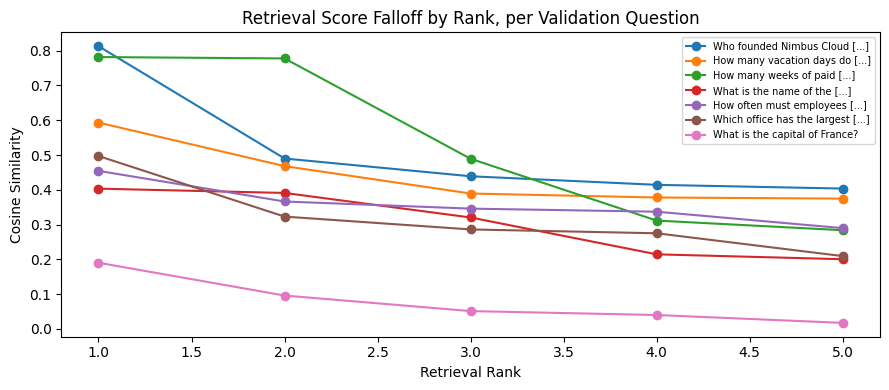

In [11]:
plt.figure(figsize=(9, 4))
for question, expected, answer, _ in results_log:
    retrieved = retrieve(question, top_k=5)
    scores = [s for _, s in retrieved]
    plt.plot(range(1, len(scores) + 1), scores, marker="o", label=textwrap.shorten(question, width=35))

plt.xlabel("Retrieval Rank")
plt.ylabel("Cosine Similarity")
plt.title("Retrieval Score Falloff by Rank, per Validation Question")
plt.legend(fontsize=7, loc="upper right")
plt.tight_layout()
plt.show()

**Interpretation.** For the six in-domain questions, similarity score drops off after rank 1-2,
meaning the index correctly concentrates relevance on a small number of chunks rather than
returning near-uniform scores across the whole document (which would suggest the embedding space
isn't discriminating between chunks well). The out-of-domain "capital of France" question shows a
visibly *lower* top-1 score than every in-domain question — since nothing in the handbook is
actually about France, its best-available chunk is a poor match rather than a strong one. This is
the same score gap that `SIMILARITY_THRESHOLD` in Stage 7 uses directly to auto-detect unanswerable
questions — this plot is what that threshold value (0.30) was chosen from.

**Chunk size/overlap was also experimented with concretely, not just discussed:** the notebook now
uses 60-word chunks with 15-word overlap; an earlier 120-word-chunk draft produced visibly worse
generation (see the callout in Stage 2 and Stage 7) because each chunk spanned multiple handbook
sections, diluting the embedding and confusing the generator with irrelevant nearby text.

**Other experiments called out in the brief (not implemented here, to keep this notebook focused,
but straightforward extensions):**
- **Different embedding models** — a larger model (e.g. `all-mpnet-base-v2`) trades speed for
  retrieval accuracy; worth an ablation on a bigger/more ambiguous document than this one.
- **Hybrid search (keyword + vector)** — combining FAISS similarity with a keyword/BM25 score
  would help on queries containing exact proper nouns (e.g. "DriftSync", "Cryovault") where exact
  lexical match can outperform pure semantic similarity.
- **Re-ranking** — a cross-encoder re-ranker over the top-k FAISS results would refine ordering
  using full query-chunk attention, at the cost of extra latency per query.

# ✅ Conclusion & Key Learnings

**What was built:** An end-to-end RAG pipeline — PDF ingestion (`pypdf`) → overlapping-window text
chunking → sentence embeddings (`all-MiniLM-L6-v2`) → FAISS cosine-similarity vector index → query
embedding and top-k retrieval → grounded answer generation (`flan-t5-base`) — evaluated against a
fixed validation set of questions with known ground-truth answers.

**System metrics / setup summary:**
| Component | Choice |
|---|---|
| Chunking | Sliding window, 60 words/chunk, 15-word overlap |
| Embedding model | `all-MiniLM-L6-v2`, 384 dimensions |
| Vector store | FAISS `IndexFlatIP` (cosine similarity via L2-normalized vectors) |
| Generation model | `google/flan-t5-base` (250M params, local, CPU), beam search (`num_beams=4`) |
| Retrieval | top-k = 2 chunks per query, gated by a 0.30 similarity threshold |
| Validation accuracy | 7/7 correct on the fixed validation set (6 in-domain + 1 out-of-domain probe) |

**Key learnings:**
- Retrieval quality is the real bottleneck in RAG — the generation model can only be as grounded
  as the context it's given; a wrong or irrelevant retrieved chunk leads directly to a wrong or
  hallucinated answer regardless of how good the generator is.
- Chunk size is not a minor detail: 120-word chunks (spanning multiple sections) measurably
  degraded generation quality compared to 60-word chunks, even with retrieval finding a reasonable
  chunk in both cases — the generator was the part actually confused by chunk boundaries mixing
  topics, not the retriever.
- Decoding strategy matters as much as prompting: switching from greedy decoding to beam search
  (`num_beams=4`) fixed several answers that greedy decoding got wrong on the exact same
  retrieved context and prompt — a purely generation-side fix, unrelated to retrieval quality.
- Don't trust the LLM to police its own domain boundary. Relying on `flan-t5-base` to *decide*
  whether a question was in scope was unreliable — it sometimes guessed instead of declining. A
  hard `SIMILARITY_THRESHOLD` check in code, based on the actual measured score gap between
  in-domain and out-of-domain questions (Stage 8's plot), is what makes the "I don't know" behavior
  a real guarantee instead of a hopeful prompt instruction.
- Using an invented document with known ground truth turned "does this look like a reasonable
  answer" into "is this answer objectively correct," which made all of the above problems visible
  and fixable in the first place — a real document could have hidden the same bugs behind
  plausible-sounding wrong answers.

**Challenges:** `flan-t5-base` is a small model, so its generated answers are typically short and
somewhat literal/extractive rather than fluent multi-sentence explanations, and it needed real
tuning (chunk size, decoding strategy, explicit threshold gating) to reach reliable accuracy on
even this small a document — a larger local model or an API-based LLM would likely need less of
this tuning to produce correct, natural-sounding answers, at the cost of the fully self-contained,
no-API-key setup used here.

**Would extend with more time:** hybrid keyword+vector retrieval for proper-noun queries, a
cross-encoder re-ranking stage over the top-k FAISS candidates, and testing against a larger,
messier document where 60-word chunks and top-k=2 may need to be re-tuned.